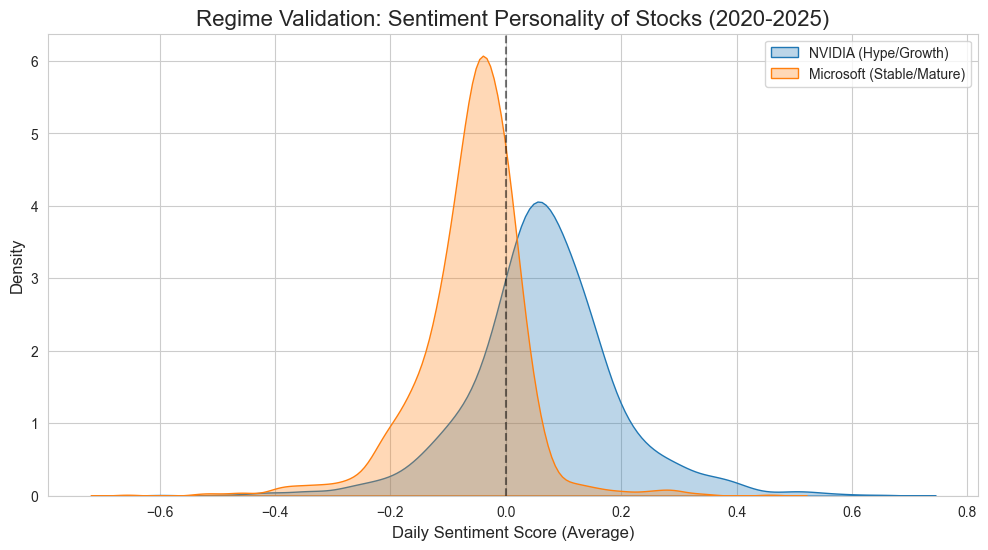

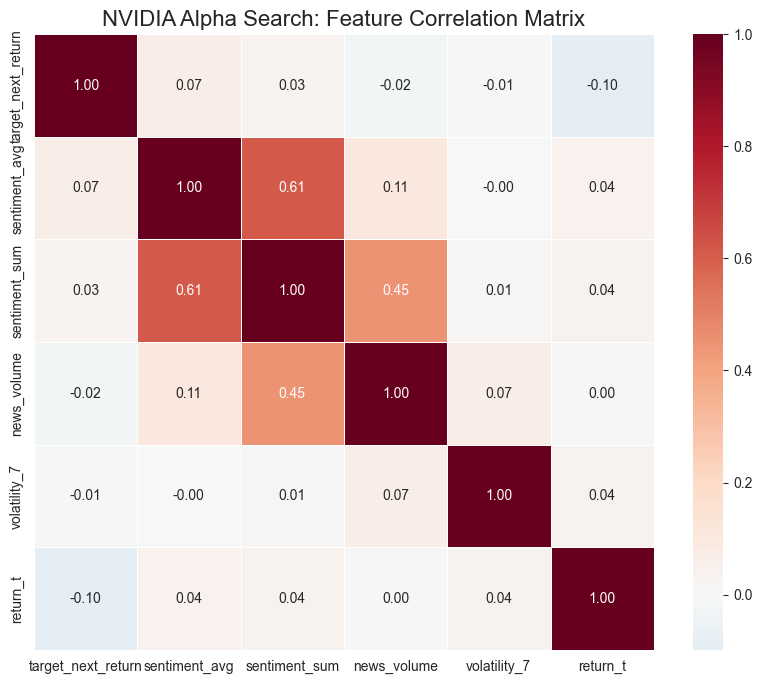

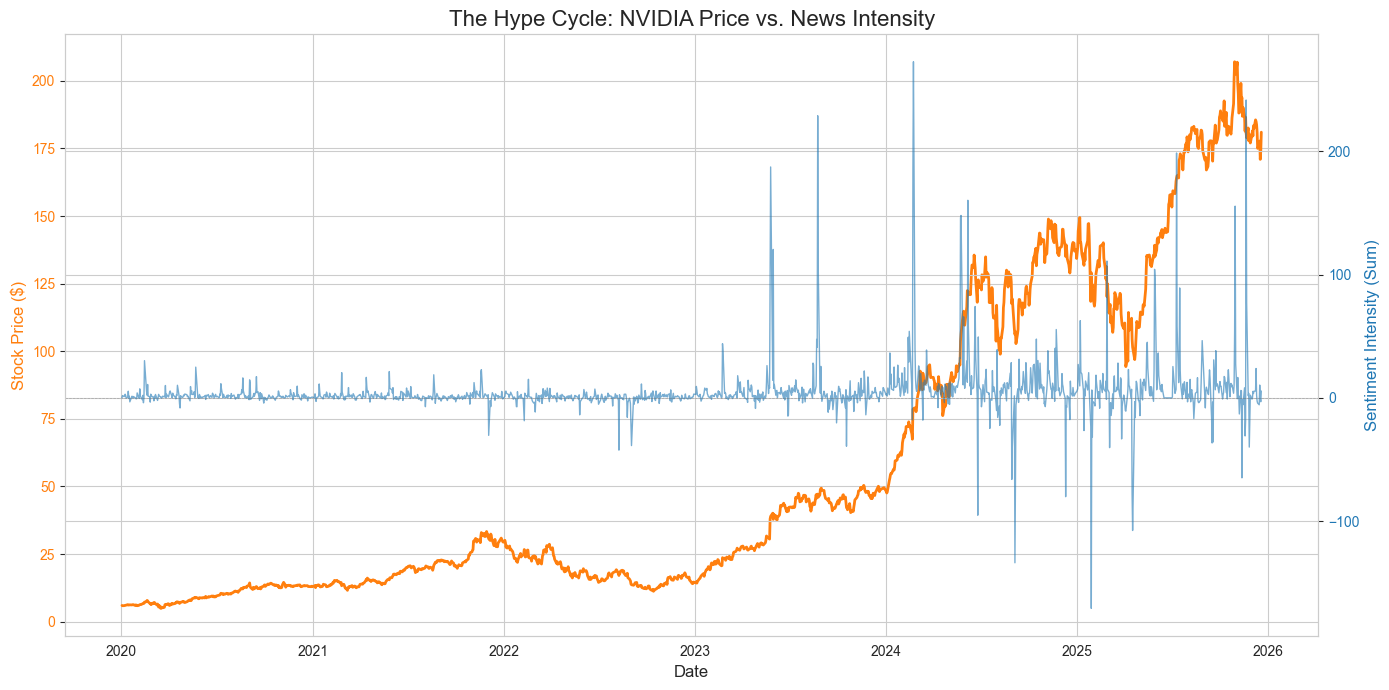

In [ ]:
# Cell: EDA Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Load the Gold Data
# Ensure this matches your actual path
file_path = "../data_pipeline/gold/ml_training_data.csv" 
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

# Filter for the two specific assets
nvda = df[df['ticker'] == 'NVDA'].copy()
msft = df[df['ticker'] == 'MSFT'].copy()

# Set global style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ==========================================
# CHART 1: THE REGIME VALIDATION (Distribution)
# Goal: Show that NVDA has a "Hype" personality (Positive Shift) vs MSFT's "Stability"
# ==========================================
plt.figure(figsize=(12, 6))

# Plot KDE (Kernel Density Estimate) for Sentiment Average
sns.kdeplot(data=nvda, x='sentiment_avg', fill=True, label='NVIDIA (Hype/Growth)', color='tab:blue', alpha=0.3)
sns.kdeplot(data=msft, x='sentiment_avg', fill=True, label='Microsoft (Stable/Mature)', color='tab:orange', alpha=0.3)

plt.title("Regime Validation: Sentiment Personality of Stocks (2020-2025)", fontsize=16)
plt.xlabel("Daily Sentiment Score (Average)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.axvline(0, color='black', linestyle='--', alpha=0.5) # Zero line
plt.legend()
plt.show()

# ==========================================
# CHART 2: THE ALPHA SIGNAL (Correlation Heatmap)
# Goal: Prove 'sentiment_avg' correlates with 'target_next_return'
# ==========================================
plt.figure(figsize=(10, 8))

# Select columns for correlation
# We focus on NVDA since that's where the signal is strongest
cols_to_corr = [
    'target_next_return', # The target
    'sentiment_avg',      # The "Quality" signal
    'sentiment_sum',      # The "Intensity" signal
    'news_volume',        # The "Attention" signal
    'volatility_7',       # Risk
    'return_t'            # Momentum
]

corr_matrix = nvda[cols_to_corr].corr()

# Plot Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title("NVIDIA Alpha Search: Feature Correlation Matrix", fontsize=16)
plt.show()

# ==========================================
# CHART 3: THE HYPE CYCLE (Dual-Axis Time Series)
# Goal: Visually prove that Sentiment Spikes (Sum) align with Price Moves
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Focus on a specific interesting period (e.g., 2023 AI Boom) or plot all
# Uncomment to zoom in: 
# zoom_start = '2023-01-01'
# nvda_zoom = nvda[nvda['date'] >= zoom_start]
nvda_zoom = nvda 

# Plot Stock Price (Left Axis)
color_price = 'tab:orange'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Stock Price ($)', color=color_price, fontsize=12)
ax1.plot(nvda_zoom['date'], nvda_zoom['close'], color=color_price, linewidth=2, label='NVDA Price')
ax1.tick_params(axis='y', labelcolor=color_price)

# Plot Sentiment Intensity (Right Axis)
ax2 = ax1.twinx()
color_sent = 'tab:blue'
ax2.set_ylabel('Sentiment Intensity (Sum)', color=color_sent, fontsize=12)
# Using 'sentiment_sum' here because it visualizes "Volume/Hype" better than Average
ax2.plot(nvda_zoom['date'], nvda_zoom['sentiment_sum'], color=color_sent, linewidth=1, alpha=0.6, label='Sentiment Sum')
ax2.tick_params(axis='y', labelcolor=color_sent)
# Add a zero line for sentiment
ax2.axhline(0, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

# Formatting
plt.title("The Hype Cycle: NVIDIA Price vs. News Intensity", fontsize=16)
fig.tight_layout()
plt.show()